Code for Subsection 3.4.2 Nonlinear Regression

In [1]:
# ============================================================
# Cell 1: Data, neural network, empirical objective, L-BFGS minimizer
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
from Algorithms import TamedSGHMC, TUSLA

GLOBAL_SEED = 2024
energy = fetch_ucirepo(id=165)
X_raw = energy.data.features.values.astype(np.float64)
y_raw = energy.data.targets.values.astype(np.float64)
X = StandardScaler().fit_transform(X_raw)
y = StandardScaler().fit_transform(y_raw)
n, m1 = X.shape
m2 = y.shape[1]

d1, eta, reg_r = 20, 1e-3, 0.5
d = d1 * m1 + d1 + m2 * d1 + m2
print(f"n={n}, input dimension m1={m1}, output dimension m2={m2}, parameter dimension d={d}")

def pack_theta(W1, b1, W2, b2): return np.concatenate([W1.ravel(), b1.ravel(), W2.ravel(), b2.ravel()])

def unpack_theta(theta):
    theta = np.asarray(theta, dtype=np.float64); idx = 0
    W1 = theta[idx:idx + d1 * m1].reshape(d1, m1); idx += d1 * m1
    b1 = theta[idx:idx + d1]; idx += d1
    W2 = theta[idx:idx + m2 * d1].reshape(m2, d1); idx += m2 * d1
    b2 = theta[idx:idx + m2]
    return W1, b1, W2, b2

def random_initial_theta(rng, scale=0.1):
    W1 = rng.normal(0.0, scale / np.sqrt(m1), size=(d1, m1))
    b1 = np.zeros(d1)
    W2 = rng.normal(0.0, scale / np.sqrt(d1), size=(m2, d1))
    b2 = np.zeros(m2)
    return pack_theta(W1, b1, W2, b2)

def forward(theta, X_batch):
    W1, b1, W2, b2 = unpack_theta(theta)
    S = X_batch @ W1.T + b1
    A = np.maximum(S, 0.0)
    pred = A @ W2.T + b2
    return pred, S, A

def empirical_objective(theta):
    theta = np.asarray(theta, dtype=np.float64)
    pred, _, _ = forward(theta, X)
    loss = np.mean(np.sum((pred - y) ** 2, axis=1))
    norm_theta = np.linalg.norm(theta)
    reg = eta / (2.0 * (reg_r + 1.0)) * norm_theta ** (2.0 * (reg_r + 1.0))
    return loss + reg

def empirical_gradient(theta):
    theta = np.asarray(theta, dtype=np.float64)
    W1, b1, W2, b2 = unpack_theta(theta)
    pred, S, A = forward(theta, X)
    dPred = 2.0 * (pred - y) / n
    grad_W2, grad_b2 = dPred.T @ A, np.sum(dPred, axis=0)
    dS = (dPred @ W2) * (S > 0.0)
    grad_W1, grad_b1 = dS.T @ X, np.sum(dS, axis=0)
    grad_loss = pack_theta(grad_W1, grad_b1, grad_W2, grad_b2)
    norm_theta = np.linalg.norm(theta)
    grad_reg = np.zeros_like(theta) if norm_theta == 0 else eta * norm_theta ** (2.0 * reg_r) * theta
    return grad_loss + grad_reg

def stochastic_gradient_minibatch(theta, batch):
    Xb, yb = batch
    theta = np.asarray(theta, dtype=np.float64)
    Xb = np.asarray(Xb, dtype=np.float64)
    yb = np.asarray(yb, dtype=np.float64)
    B = Xb.shape[0]
    W1, b1, W2, b2 = unpack_theta(theta)
    S = Xb @ W1.T + b1
    A = np.maximum(S, 0.0)
    pred = A @ W2.T + b2
    dPred = 2.0 * (pred - yb) / B
    grad_W2, grad_b2 = dPred.T @ A, np.sum(dPred, axis=0)
    dS = (dPred @ W2) * (S > 0.0)
    grad_W1, grad_b1 = dS.T @ Xb, np.sum(dS, axis=0)
    grad_loss = pack_theta(grad_W1, grad_b1, grad_W2, grad_b2)
    norm_theta = np.linalg.norm(theta)
    grad_reg = np.zeros_like(theta) if norm_theta == 0 else eta * norm_theta ** (2.0 * reg_r) * theta
    return grad_loss + grad_reg

def H_minibatch(theta, batch): return stochastic_gradient_minibatch(theta, batch)

def estimate_u_star_lbfgs(n_starts=30, maxiter=5000, seed=2024, init_scale=1.0):
    rng = np.random.default_rng(seed)
    best_theta, best_value, results = None, np.inf, []
    for s in range(n_starts):
        theta0 = random_initial_theta(rng, scale=init_scale)
        res = minimize(fun=empirical_objective, x0=theta0, jac=empirical_gradient, method="L-BFGS-B", options={"maxiter": maxiter, "ftol": 1e-12, "gtol": 1e-8, "maxls": 50, "disp": False})
        value = empirical_objective(res.x)
        results.append((value, res))
        if value < best_value:
            best_theta, best_value = res.x.copy(), value
    return best_theta, best_value, results

theta_star_hat, u_star_hat, lbfgs_results = estimate_u_star_lbfgs(n_starts=30, maxiter=5000, seed=GLOBAL_SEED, init_scale=1.0)
print(f"\nEstimated empirical infimum u_star_hat = {u_star_hat:.12e}")

n=1030, input dimension m1=8, output dimension m2=1, parameter dimension d=201

Estimated empirical infimum u_star_hat = 9.742077487200e-02


Running Experiment 1: Path of Expected Excess Risk ...
Experiment 1 completed.
  tusla_values shape:  (30, 1001)
  tsghmc_values shape: (30, 1001)
  final excess risk TUSLA:  7.640702e-03
  final excess risk tSGHMC: 5.307063e-03


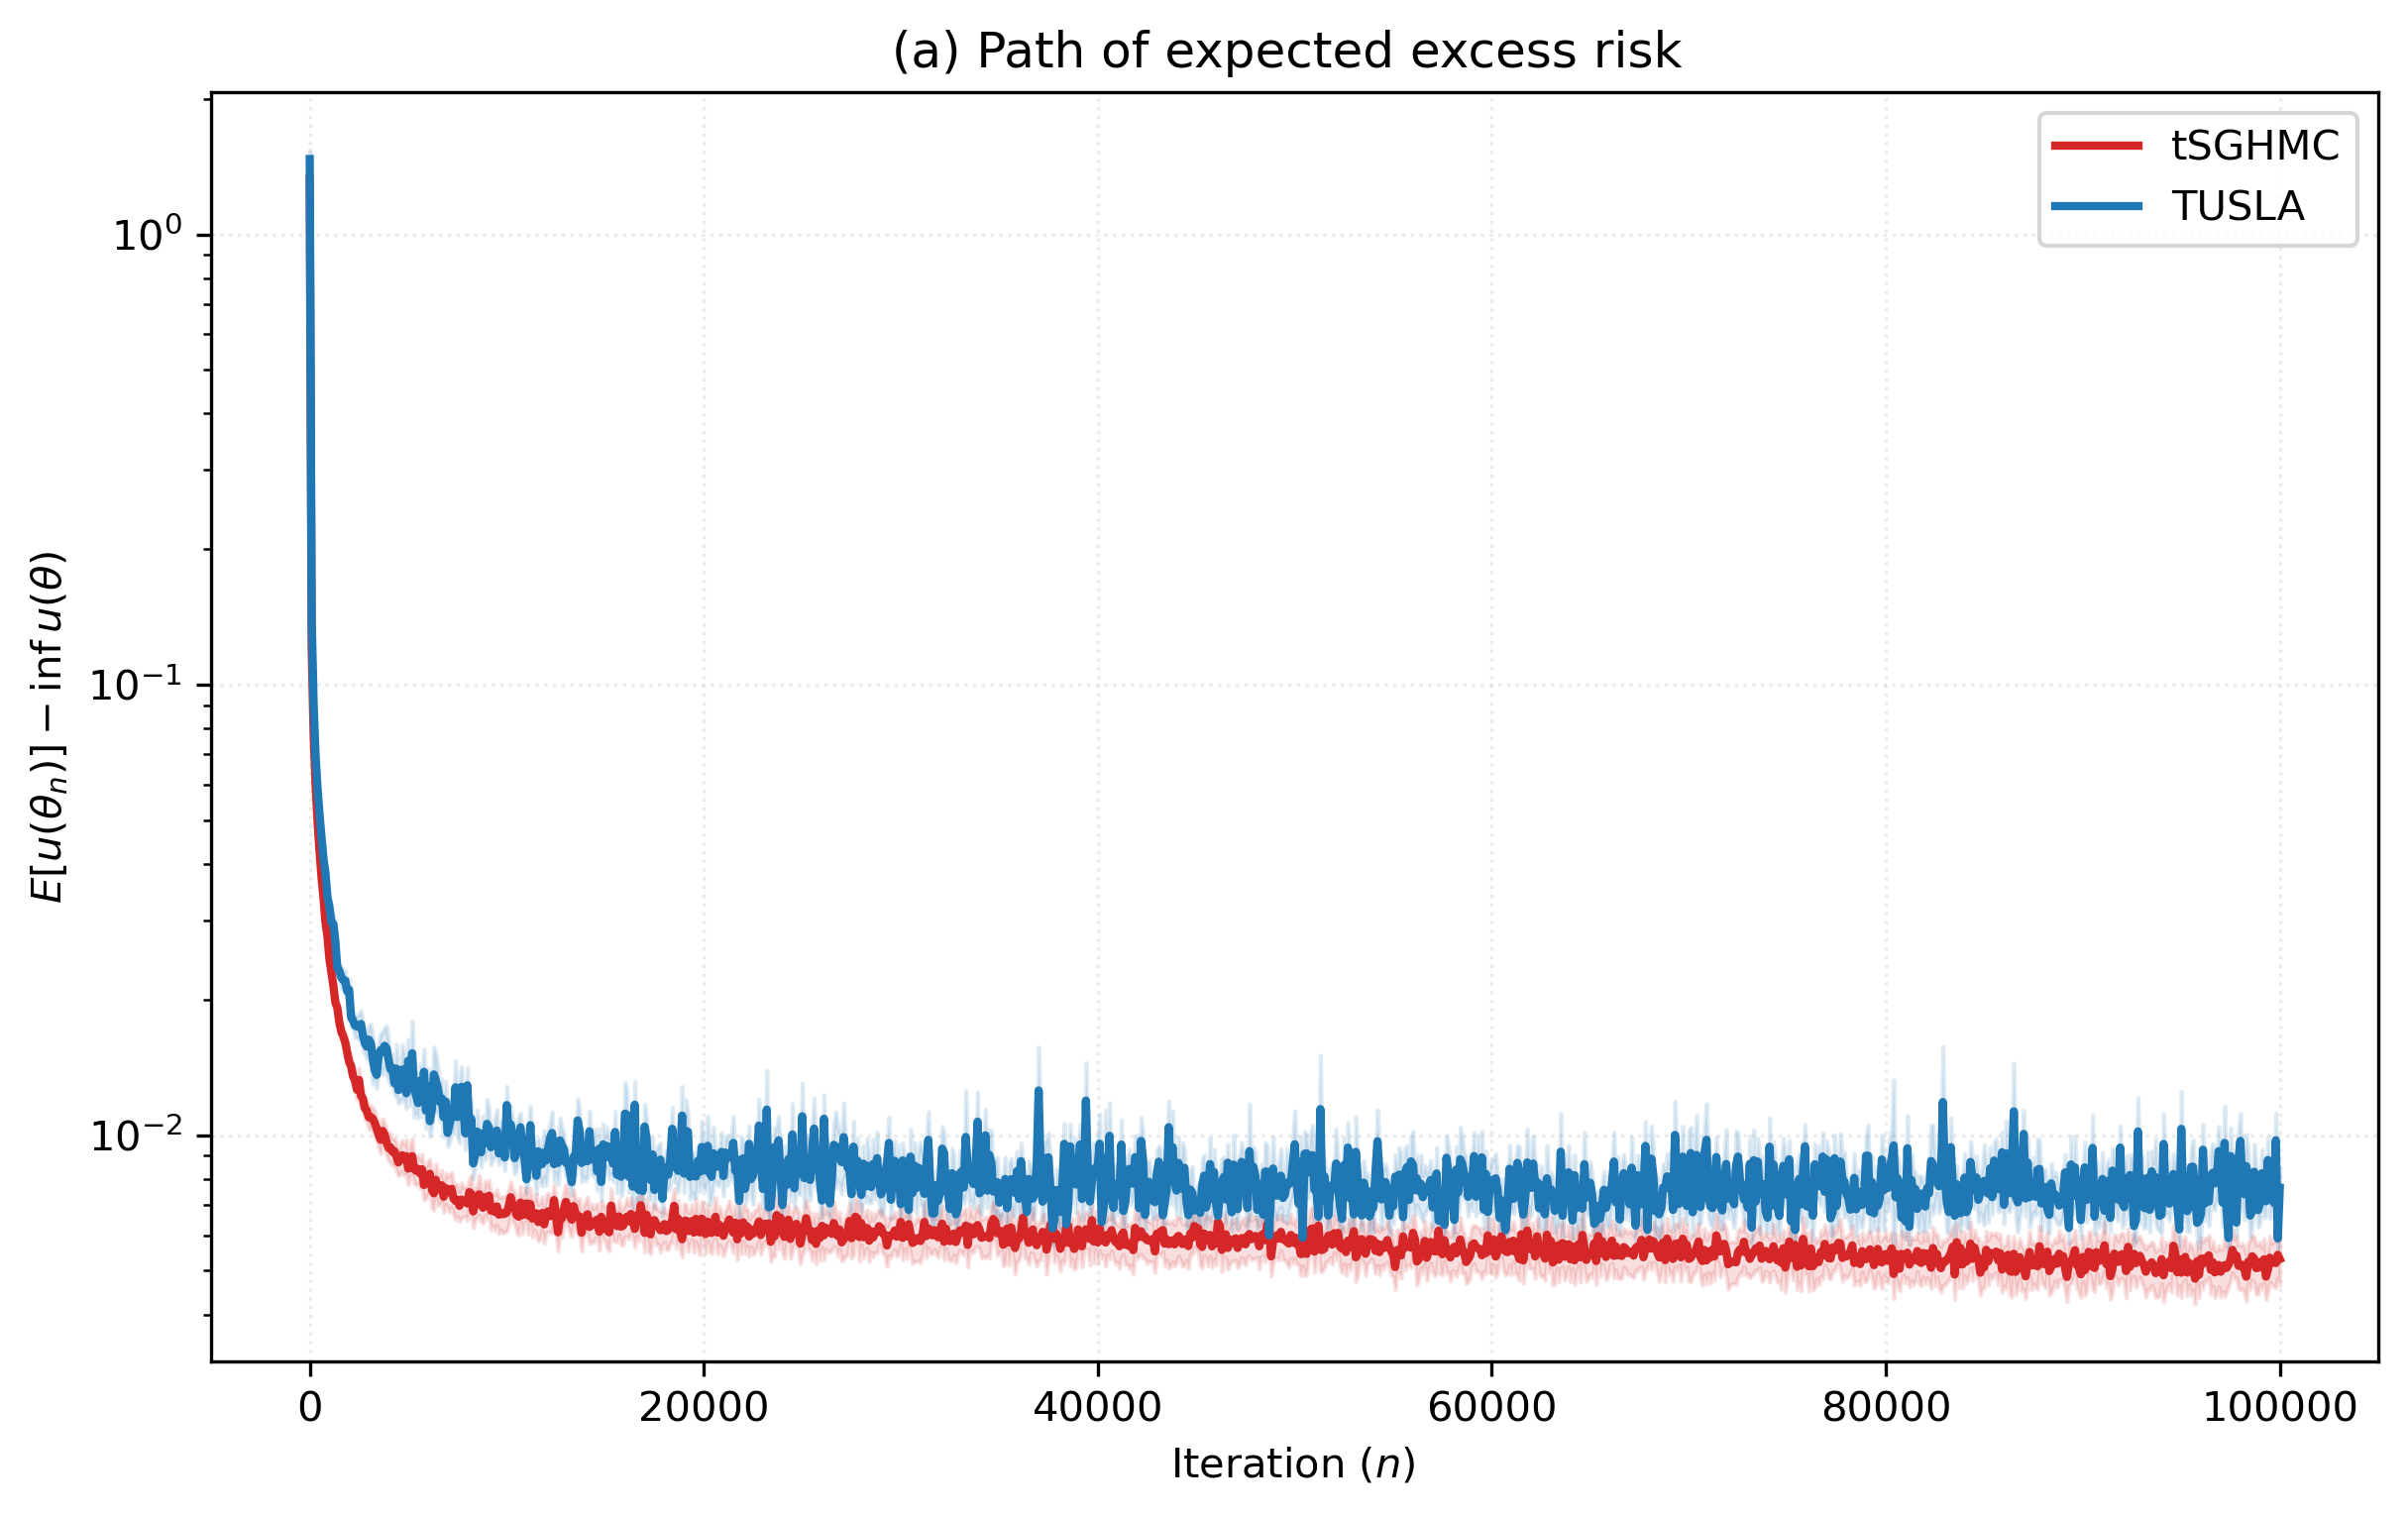


Running Experiment 2: RMSE self-reference experiment ...
Experiment 2 rmse empirical values:
  step_size=5.00e-04, rmse_TUSLA_self=5.191126e-02, rmse_tSGHMC_self=3.985205e-03
  step_size=6.95e-04, rmse_TUSLA_self=6.765378e-02, rmse_tSGHMC_self=4.315175e-03
  step_size=9.65e-04, rmse_TUSLA_self=8.583455e-02, rmse_tSGHMC_self=5.057237e-03
  step_size=1.34e-03, rmse_TUSLA_self=1.071740e-01, rmse_tSGHMC_self=5.744911e-03
  step_size=1.86e-03, rmse_TUSLA_self=1.299110e-01, rmse_tSGHMC_self=6.411939e-03
  step_size=2.59e-03, rmse_TUSLA_self=1.570282e-01, rmse_tSGHMC_self=7.758265e-03
  step_size=3.60e-03, rmse_TUSLA_self=1.875644e-01, rmse_tSGHMC_self=9.180262e-03
  step_size=5.00e-03, rmse_TUSLA_self=2.229336e-01, rmse_tSGHMC_self=1.072988e-02

Estimated log-log slope (TUSLA self-reference):  0.626266
Estimated log-log slope (tSGHMC self-reference):  0.437963
  rmse_errors_tusla shape:  (30, 8)
  rmse_errors_tsghmc shape: (30, 8)


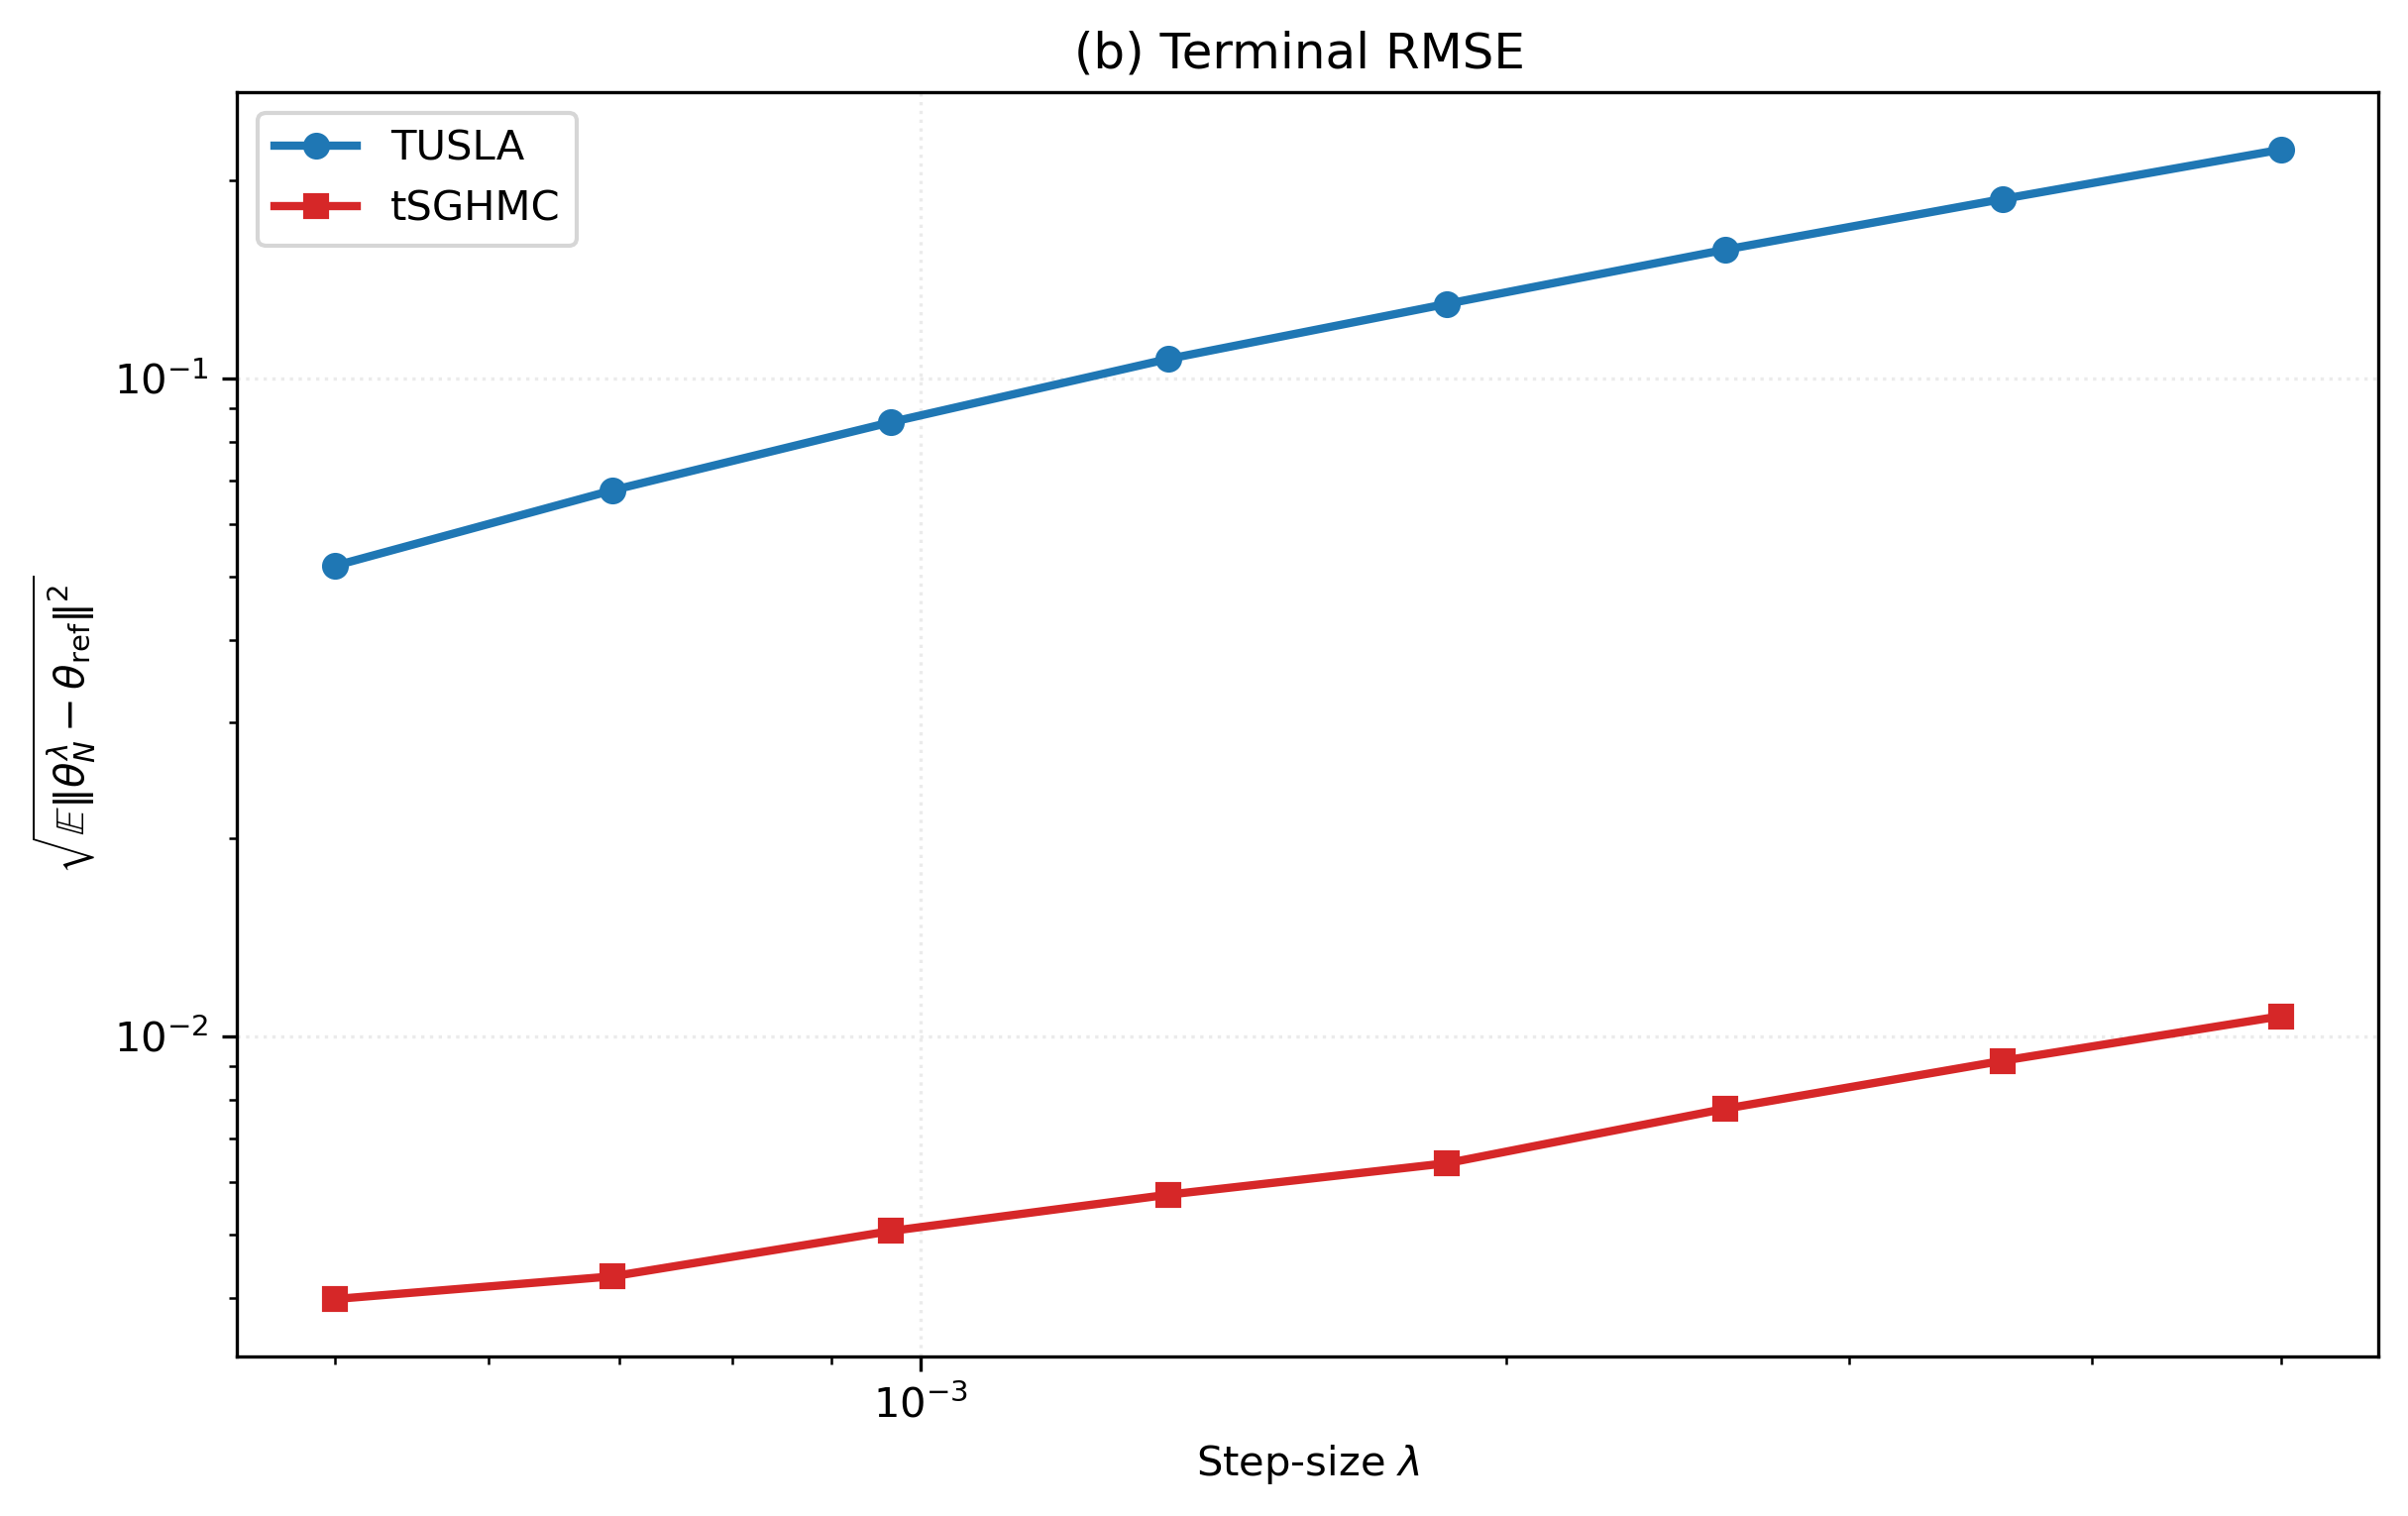

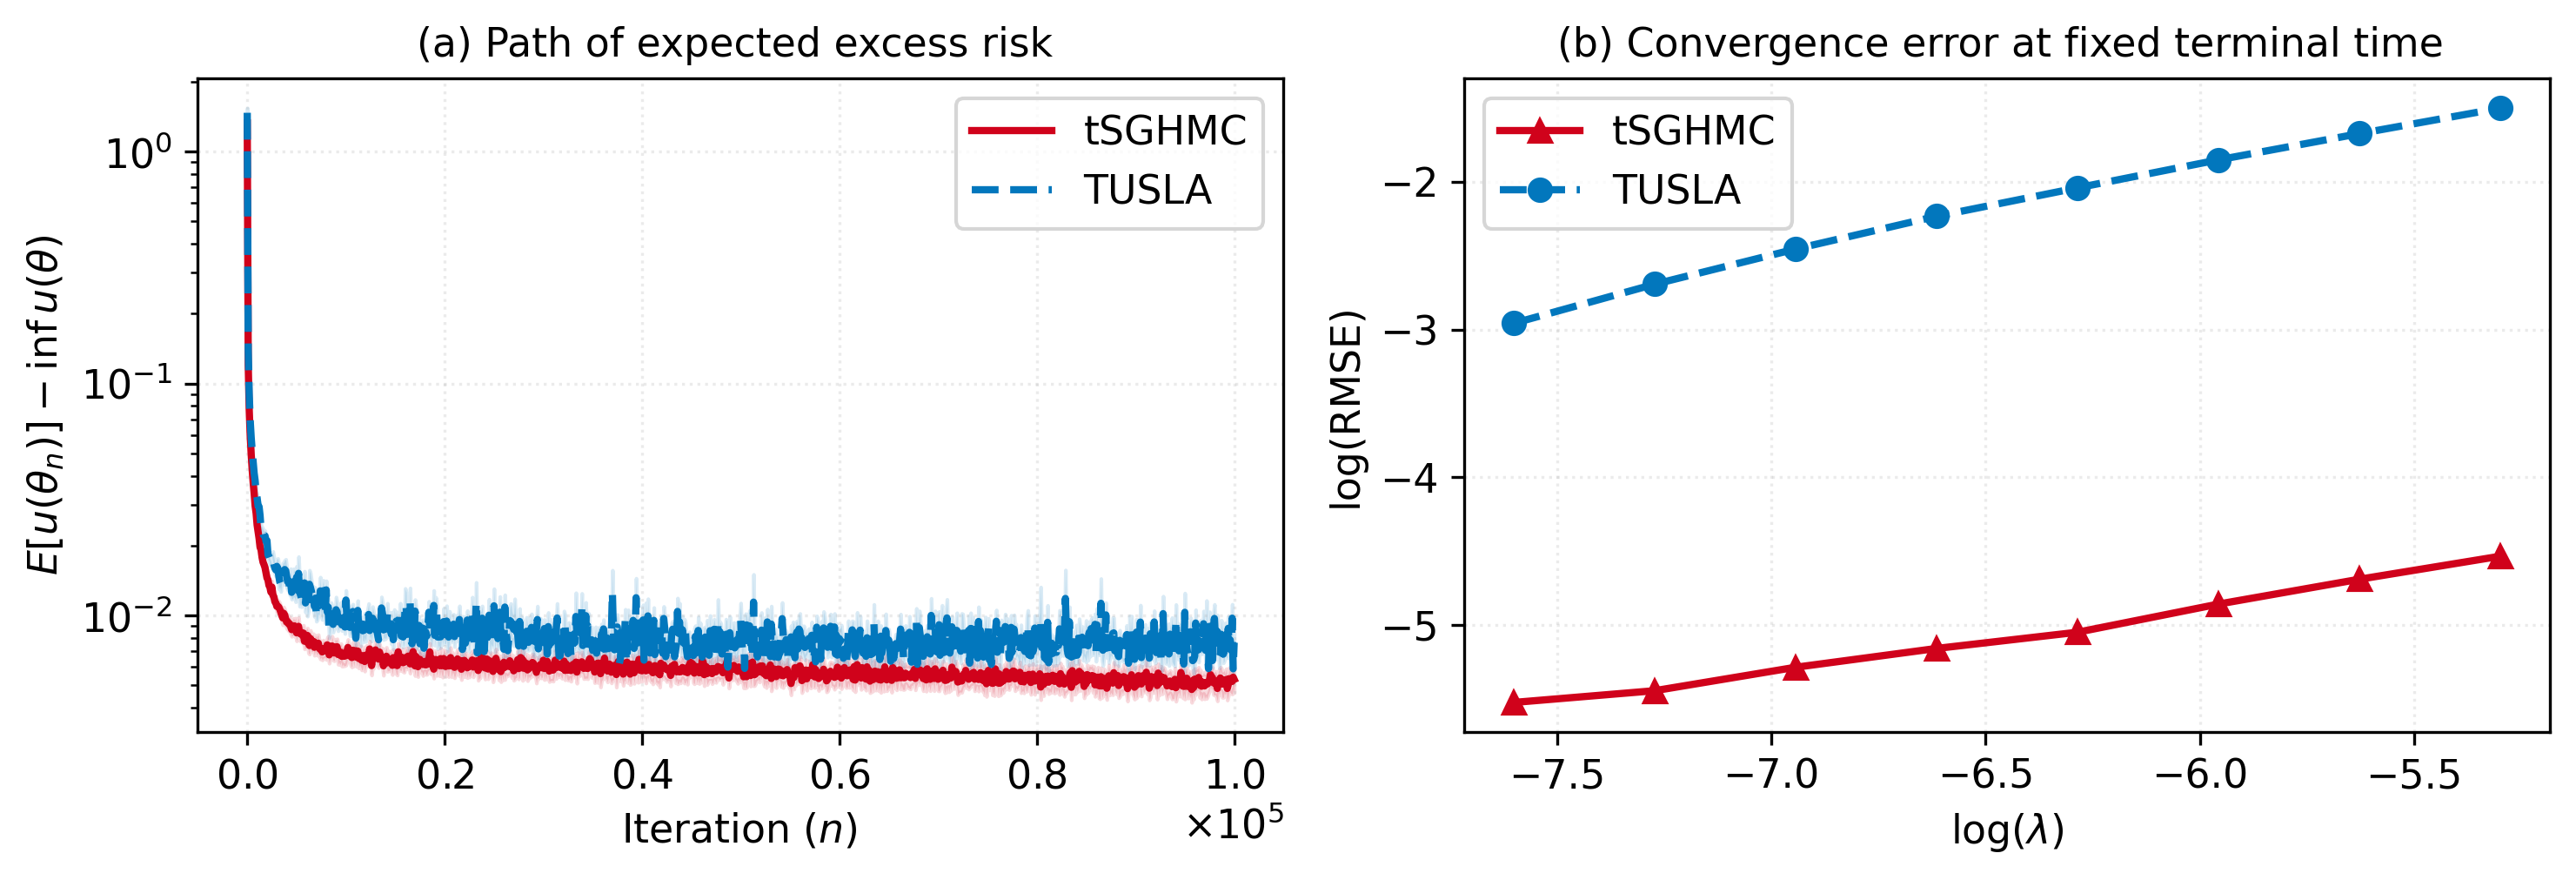

In [ ]:
# ============================================================
# Cell 2: Path of Expected Excess Risk + RMSE Plot + Combined Plot
# ============================================================

# -----------------------------
# Shared settings
# -----------------------------
n_runs = 30
batch_size = 256
beta = 1e10
gamma = 0.5
m_split = 1e-10
tame_r = 0.5
init_scale = 1.0

def sample_minibatch(rng, batch_size):
    idx = rng.integers(0, n, size=batch_size)
    return X[idx], y[idx]

def make_algorithm(alg_name, lr):
    if alg_name == "TUSLA":
        return TUSLA(H=H_minibatch, lr=lr, beta=beta, r=tame_r)
    if alg_name == "tSGHMC":
        return TamedSGHMC(H=H_minibatch, lr=lr, gamma=gamma, beta=beta, m=m_split, r=tame_r)
    raise ValueError("alg_name must be either 'TUSLA' or 'tSGHMC'.")

# ============================================================
# Experiment 1: Path of Expected Excess Risk
# ============================================================

path_n_steps = 100000
path_lr = 0.5
record_every = 100
path_base_seed = 12345
eval_iters = np.arange(0, path_n_steps + 1, record_every)

def run_path_once(alg_name, seed, n_steps=path_n_steps, lr=path_lr, record_every=record_every, batch_size=batch_size):
    rng = np.random.default_rng(seed)
    theta = random_initial_theta(rng, scale=init_scale)
    alg = make_algorithm(alg_name, lr)
    values = []
    if alg_name == "TUSLA":
        for k in range(n_steps + 1):
            if k % record_every == 0:
                values.append(empirical_objective(theta))
            if k < n_steps:
                theta = alg.step(theta, x=sample_minibatch(rng, batch_size), rng=rng)
        return np.array(values)
    velocity = np.zeros_like(theta)
    for k in range(n_steps + 1):
        if k % record_every == 0:
            values.append(empirical_objective(theta))
        if k < n_steps:
            theta, velocity = alg.step(theta, velocity, x=sample_minibatch(rng, batch_size), rng=rng)
    return np.array(values)

print("Running Experiment 1: Path of Expected Excess Risk ...")
tusla_values = np.array([run_path_once("TUSLA", path_base_seed + run) for run in range(n_runs)])
tsghmc_values = np.array([run_path_once("tSGHMC", path_base_seed + 10000 + run) for run in range(n_runs)])

tusla_excess = np.maximum(tusla_values - u_star_hat, 1e-16)
tsghmc_excess = np.maximum(tsghmc_values - u_star_hat, 1e-16)
tusla_mean = np.mean(tusla_excess, axis=0)
tsghmc_mean = np.mean(tsghmc_excess, axis=0)
tusla_std = np.std(tusla_excess, axis=0)
tsghmc_std = np.std(tsghmc_excess, axis=0)
tusla_se = tusla_std / np.sqrt(n_runs)
tsghmc_se = tsghmc_std / np.sqrt(n_runs)

print("Experiment 1 completed.")
print(f"  tusla_values shape:  {tusla_values.shape}")
print(f"  tsghmc_values shape: {tsghmc_values.shape}")
print(f"  final excess risk TUSLA:  {tusla_mean[-1]:.6e}")
print(f"  final excess risk tSGHMC: {tsghmc_mean[-1]:.6e}")

fig, ax = plt.subplots(figsize=(8.2, 5.2), dpi=300)
ax.plot(eval_iters, tsghmc_mean, color="#d62728", linewidth=2.0, label="tSGHMC")
ax.fill_between(eval_iters, np.maximum(tsghmc_mean - tsghmc_se, 1e-16), tsghmc_mean + tsghmc_se, color="#d62728", alpha=0.15)
ax.plot(eval_iters, tusla_mean, color="#1f77b4", linewidth=2.0, label="TUSLA")
ax.fill_between(eval_iters, np.maximum(tusla_mean - tusla_se, 1e-16), tusla_mean + tusla_se, color="#1f77b4", alpha=0.15)
ax.set_yscale("log")
ax.set_xlabel(r"Iteration $(n)$ ")
ax.set_ylabel(r"$E[u(\theta_n)]-\inf u( \theta)$")
ax.set_title(r"(a) Path of expected excess risk ")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

# ============================================================
# Experiment 2: RMSE Plot
# ============================================================

T = 10.0
lambda_ref = 1e-4
lambda_list = np.exp(np.linspace(np.log(5e-4), np.log(5e-3), 8))
rmse_base_seed = 202500


def run_to_terminal_time(alg_name, theta0, lr, T, seed, batch_size=batch_size):
    rng = np.random.default_rng(seed)
    alg = make_algorithm(alg_name, lr)
    theta = theta0.copy()
    n_steps = int(np.floor(T / lr))
    if alg_name == "TUSLA":
        for _ in range(n_steps):
            theta = alg.step(theta, x=sample_minibatch(rng, batch_size), rng=rng)
        return theta
    velocity = np.zeros_like(theta)
    for _ in range(n_steps):
        theta, velocity = alg.step(theta, velocity, x=sample_minibatch(rng, batch_size), rng=rng)
    return theta

def one_replication_rmse_experiment(alg_name, seed, lambda_list, lambda_ref, T, batch_size=batch_size, init_scale=init_scale):
    rng_init = np.random.default_rng(seed)
    theta0 = random_initial_theta(rng_init, scale=init_scale)
    theta_ref = run_to_terminal_time(alg_name, theta0, lambda_ref, T, seed + 100000, batch_size)
    errors_sq = []
    for j, lr in enumerate(lambda_list):
        theta_lr = run_to_terminal_time(alg_name, theta0, lr, T, seed + 200000 + j, batch_size)
        errors_sq.append(np.linalg.norm(theta_lr - theta_ref) ** 2)
    return np.array(errors_sq)

print("\nRunning Experiment 2: RMSE self-reference experiment ...")
rmse_errors_tusla = np.array([one_replication_rmse_experiment("TUSLA", rmse_base_seed + run, lambda_list, lambda_ref, T, batch_size, init_scale) for run in range(n_runs)])
rmse_errors_tsghmc = np.array([one_replication_rmse_experiment("tSGHMC", rmse_base_seed + 10000 + run, lambda_list, lambda_ref, T, batch_size, init_scale) for run in range(n_runs)])

rmse_TUSLA_self = np.sqrt(np.mean(rmse_errors_tusla, axis=0))
rmse_tSGHMC_self = np.sqrt(np.mean(rmse_errors_tsghmc, axis=0))
slope_TUSLA_self = np.polyfit(np.log(lambda_list), np.log(rmse_TUSLA_self), deg=1)[0]
slope_tSGHMC_self = np.polyfit(np.log(lambda_list), np.log(rmse_tSGHMC_self), deg=1)[0]

print("Experiment 2 rmse empirical values:")
for lr, rmse_tusla, rmse_tsghmc in zip(lambda_list, rmse_TUSLA_self, rmse_tSGHMC_self):
    print(f"  step_size={lr:.2e}, rmse_TUSLA_self={rmse_tusla:.6e}, rmse_tSGHMC_self={rmse_tsghmc:.6e}")
print()
print(f"Estimated log-log slope (TUSLA self-reference):  {slope_TUSLA_self:.6f}")
print(f"Estimated log-log slope (tSGHMC self-reference):  {slope_tSGHMC_self:.6f}")
print(f"  rmse_errors_tusla shape:  {rmse_errors_tusla.shape}")
print(f"  rmse_errors_tsghmc shape: {rmse_errors_tsghmc.shape}")

fig, ax = plt.subplots(figsize=(8.2, 5.2), dpi=300)
ax.plot(lambda_list, rmse_TUSLA_self, color="#1f77b4", marker="o", linewidth=2.0, markersize=5.5, label="TUSLA")
ax.plot(lambda_list, rmse_tSGHMC_self, color="#d62728", marker="s", linewidth=2.0, markersize=5.5, label="tSGHMC")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Step-size $\lambda$")
ax.set_ylabel(r"$\sqrt{\mathbb{E}\|\theta_N^\lambda-\theta_{\mathrm{ref}}\|^2}$")
ax.set_title(r"(b) Terminal RMSE ")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

# ============================================================
# Combined Plot
# ============================================================

plt.rcParams.update({"font.size": 11, "axes.labelsize": 11, "axes.titlesize": 11, "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11})
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300)

ax = axes[0]
ax.plot(eval_iters, tsghmc_mean, color="#d0021b", linewidth=2.0, label="tSGHMC")
ax.fill_between(eval_iters, np.maximum(tsghmc_mean - tsghmc_se, 1e-16), tsghmc_mean + tsghmc_se, color="#d0021b", alpha=0.15)
ax.plot(eval_iters, tusla_mean, color="#0277bd", linewidth=2.0, linestyle="--", label="TUSLA")
ax.fill_between(eval_iters, np.maximum(tusla_mean - tusla_se, 1e-16), tusla_mean + tusla_se, color="#0277bd", alpha=0.15)
ax.set_yscale("log")
ax.set_xlabel(r"Iteration $(n)$ ")
ax.set_ylabel(r"$E[u(\theta_n)]-\inf u( \theta)$")
ax.set_title("(a) Path of expected excess risk ")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True)
sf_iter = ScalarFormatter(useMathText=True)
sf_iter.set_scientific(True)
sf_iter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(sf_iter)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

ax = axes[1]
ax.plot(np.log(lambda_list), np.log(rmse_tSGHMC_self), color="#d0021b", marker="^", linewidth=2.0, markersize=6.0, label="tSGHMC")
ax.plot(np.log(lambda_list), np.log(rmse_TUSLA_self), color="#0277bd", marker="o", linestyle="--", linewidth=2.0, markersize=6.0, label="TUSLA")
ax.set_xlabel(r"$\log(\lambda)$")
ax.set_ylabel("log(RMSE)")
ax.set_title("(b) Convergence error at fixed terminal time ")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True, loc="best")

fig.tight_layout()
plt.show()
# fig.savefig("Example4_NN.png", dpi=220, bbox_inches="tight")